# Background

Author: Diane Menuz, based on script from Paul Inkenbrandt  
Date: 8/6/2026  
  
Purpose: Template for calculating ET-weighted daily and monthly footprint values using  
ffp_xr, which is the closest model to the published Kljun Python footprint code. Example  
includes calculating z0 and zm, weighting by NLDAS ETo values (taking data from the  
[nldas notebook example](docs\notebooks\nldas_et_download_example.ipynb)), and then calculating and exporting daily and monthly  
footprints.  
  
The footprint calculations in this example for creating June and July 2021 rasters took  
about 2 seconds to run when saving the outputs to a local drive, but at times  
significantly longer when saving to a networked drive.

# Parameters and Libraries

In [2]:
# parameters to change or review for each run
STATIONID = 'US-UTW'
STATION_LAT  = 39.4452
STATION_LON  = -110.7287
# subset of data that you want to develop footprints for
# you must include the time of day!!
START = "2021-06-01 00:00"
END   = "2021-07-31 23:30"
# time of data subset for data, 8:00 to 20:00 follows Volk (2023)
# you could do 0 to 23 if you want all data
START_TIME = 8
END_TIME = 20
DX, DY = 10.0, 10.0   # output raster resolution
DOMAIN = (-600.0, 600.0, -600.0, 600.0)   
DATA_FREQ = '30min' # set to the data frequency, used to resample nldas et data to match tower data

In [3]:
# parameters to automate in pipeline based on folders location and stationid
OUT_DIR = f"D:/footprints/{STATIONID}"
DAT_PATH = f'input_data/{STATIONID}_footprint.parquet' # path to input
NLDAS_ET_PATH= f"input_data/{STATIONID}_nldas.csv"

In [4]:
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import sys
sys.path.append("../../src")
from fluxfootprints.ffp_daily_monthly_helper import (
    load_config,
    build_climatology,
    summarize_periods,
    export_rasters_geotiff,
    compute_aerodynamic_params
)

In [5]:
# set up output directory and pull station lat and long from config file
OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(exist_ok=True)

## Read in Data and Filter to Analysis Period

- Read in eddy covariance data file and create datetime index for start of record
- Compute aerodynamic parameters (z0 and zm)
- Read in NLDAS ET values and join to eddy covariance data frame
- Subset out time of interest

In [6]:
# read in data and update to datetime_start index
df_all = pd.read_parquet(DAT_PATH)
df_all['datetime_start'] = df_all.index - pd.Timedelta(DATA_FREQ)
df_all = df_all.reset_index().set_index('datetime_start')
# computer z0 and zm
df_all = compute_aerodynamic_params(df_all, 
                                       inst_height = 'measurement_height',
                                       crop_height='crop_height_m', 
                                       veg_type='alfalfa')
# merge with nldas data
nldas = pd.read_csv(NLDAS_ET_PATH, 
                    parse_dates=['timestamp_local'], 
                    index_col='timestamp_local')
nldas.rename(columns={'eto_grass':'nldas_et'}, inplace=True)
nldas_resample = nldas.resample(DATA_FREQ).ffill()
df_all = df_all.merge(nldas_resample['nldas_et'],
                    left_index=True,
                    right_index=True,
                    how='inner')
assert df_all.nldas_et.isna().sum() == 0, 'Some records missing nldas ET data'
# subset out by dates and time of day
mask = (df_all.index>=START) & (df_all.index<=END)
df_all = df_all[mask]
mask = (df_all.index.hour>=START_TIME) & (df_all.index.hour<=END_TIME)
df_all = df_all[mask]

## Month-by-month Footprint Calculation

For each month the workflow is:

1. **`build_climatology`** – runs the Kljun et al. 2-D FFP model on every
   valid half-hour and stacks results into an xarray Dataset.
2. **`summarize_periods`** – aggregates the per-timestep footprint stack into
   daily and monthly summary rasters (arithmetic mean and ET-flux-weighted).
3. **`export_rasters_geotiff`** – writes the four raster types to GeoTIFFs
   in local UTM at the station's lat/lon origin.

`gc.collect()` after each month releases the large xarray objects immediately
rather than waiting for Python's garbage collector.

In [9]:
months = pd.period_range(start=START, end=END, freq="M")
print(f"Processing {len(months)} months: {months[0]} – {months[-1]}")

results = []    # collect per-month summaries for the table below
skipped = []
domain_results = []

for period in months:
    label       = str(period)               # e.g. "2023-01"
    yyyymm      = label.replace("-", "")    # e.g. "202301"
    slice_start = period.start_time.strftime("%Y-%m-%d")
    slice_end   = period.end_time.strftime("%Y-%m-%d")

    df_mon = df_all.loc[slice_start:slice_end].copy()

    req_fields = ["mo_length_1_1_1",
                "v_sigma_1_1_1",
                "ustar_1_1_1",
                "wd_1_1_1",
                "ws_1_1_1",
            ]
    valid_mask_mon = df_mon[req_fields].notna().all(axis=1)
    n_valid = int(valid_mask_mon.sum())

    print(f"  {label}: {len(df_mon):5d} records,  {n_valid:4d} with required fields … ", end="", flush=True)

    if n_valid < 10:
        print("SKIPPED (not enough records with required fields)")
        skipped.append(label)
        results.append({"month": label, "n_req_fields": n_valid, "status": "skipped",
                        "n_daily_tifs": 0, "n_monthly_tifs": 0})
        continue

    clim = out = None
    try:
        # ── Step 1: build footprint climatology ──────────────────────────────
        clim = build_climatology(
            df_mon,
            model_type = 'ffp_xr', #ffp_xr, ffp (which is from improved_ffp), km, ls, wang
            ustar = 'ustar_1_1_1',
            ol = 'mo_length_1_1_1',
            umean = 'ws_1_1_1',
            sigmav = 'v_sigma_1_1_1',
            wind_dir = 'wd_1_1_1',
            zm = 'zm',
            z0 = 'z0',
            h = 2000.0,
            dx=DX,
            dy=DY,
            domain=DOMAIN,
        )
        print('Climatology built')

        # ── Step 2: summarize into daily + monthly rasters ───────────────────
        out = summarize_periods(
            clim,
            df_mon,
            et_source="nldas_et",        
            is_le = False,  # if using le instead of et value
            calc_et_weighted = True, # produce ET-weighted rastrs
            daily=True,
            monthly=True,
            normalize_each_time=True,   # normalize so each daily/monthly raster will sum to 1
        )
        print('Data summarized')

        # ── Step 3: write GeoTIFFs ───────────────────────────────────────────
        export_rasters_geotiff(
            clim,
            out,
            station_lat=STATION_LAT,
            station_lon=STATION_LON,
            out_dir=OUT_DIR,
            crs_out="auto",    # auto-selects UTM zone from lat/lon
            which=("daily_mean", "monthly_mean", "daily_etw", "monthly_etw"),
            prefix=f"ffp_{STATIONID}",
            dtype="float32",
            nodata=0.0,
        )
        print('Rasters exported')

        all_month_tifs = list(OUT_DIR.glob(f"ffp_{STATIONID}_*{yyyymm}*.tif"))
        n_daily_tifs   = len([f for f in all_month_tifs if "daily"   in f.name])
        n_monthly_tifs = len([f for f in all_month_tifs if "monthly" in f.name])

        print(f"done  ({clim.ts_len} timesteps → {n_daily_tifs} daily + {n_monthly_tifs} monthly TIFs)")
        results.append({"month": label, "n_req_fields": n_valid, "status": "ok",
                        "ts_len": clim.ts_len,
                        "n_daily_tifs": n_daily_tifs, "n_monthly_tifs": n_monthly_tifs})
        domain_results.append(out.daily_domain_coverage)

    except Exception as exc:
        print(f"ERROR: {exc}")
        skipped.append(label)
        results.append({"month": label, "n_req_fields": n_valid, "status": f"error: {exc}",
                        "n_daily_tifs": 0, "n_monthly_tifs": 0})


    finally:
        del clim, out
        gc.collect()

print(f"\nFinished. Skipped months: {skipped if skipped else 'none'}")
final_domain_results = pd.concat(domain_results)
print(f'Min percent coverage: {round(final_domain_results.min_coverage_pct.min(), 1)}')
print(f'Min number of valid timesteps: {final_domain_results.valid_timesteps.min()}')

Processing 2 months: 2021-06 – 2021-07
  2021-06:   780 records,     0 with required fields … SKIPPED (not enough records with required fields)
  2021-07:   806 records,   702 with required fields … Climatology built
Data summarized
Rasters exported
done  (631 timesteps → 54 daily + 2 monthly TIFs)

Finished. Skipped months: ['2021-06']
Min percent coverage: 91.8
Min number of valid timesteps: 17


## Review Results

In [10]:
# review whether any footprints created with too few records, based on Volk (2023)
daily_required_timesteps = 10
monthly_required_timesteps = 260*2

daily_timestamp_mask = final_domain_results.valid_timesteps<daily_required_timesteps
invalid_daily_timesteps = final_domain_results[daily_timestamp_mask]
if len(invalid_daily_timesteps)>0:
    print(f'Not enough timesteps: {invalid_daily_timesteps.index}')

monthly_domain = final_domain_results.resample('M').sum()
monthly_timestamp_mask = monthly_domain.valid_timesteps<monthly_required_timesteps
invalid_monthly_timesteps = monthly_domain[monthly_timestamp_mask]
if len(invalid_monthly_timesteps)>0:
    print(f'Not enough timesteps in month for: {invalid_monthly_timesteps.index.month}')

In [11]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

  month  n_req_fields  status  n_daily_tifs  n_monthly_tifs  ts_len
2021-06             0 skipped             0               0     NaN
2021-07           702      ok            54               2   631.0


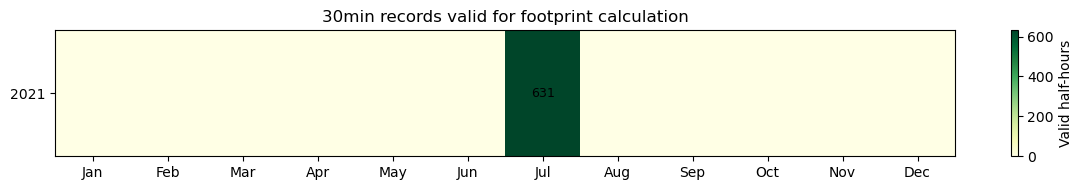

In [12]:
if (
    len(final_domain_results) > 0
    and "valid_timesteps" in final_domain_results.columns
):
    res_plot = final_domain_results.copy()

    # 1. Extract datetime from index or 'time' column
    if "time" in res_plot.columns:
        dt_index = pd.to_datetime(res_plot["time"])
    else:
        dt_index = pd.to_datetime(res_plot.index)

    res_plot["year"] = dt_index.year
    res_plot["month_n"] = dt_index.month

    # 2. Aggregate daily counts to monthly sums using pivot_table
    pivot = res_plot.pivot_table(
        index="year",
        columns="month_n",
        values="valid_timesteps",
        aggfunc="sum",
    )

    # 3. Ensure all 12 months (1-12) exist in order, filling missing months with 0
    pivot = pivot.reindex(columns=range(1, 13), fill_value=0).fillna(0)

    month_labels = [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ]

    # 4. Plot heatmap
    fig, ax = plt.subplots(figsize=(12, max(2, len(pivot) * 1.2)))
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlGn", vmin=0)

    ax.set_xticks(range(12))
    ax.set_xticklabels(month_labels)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index)

    # 5. Annotate monthly values on grid
    for r, yr in enumerate(pivot.index):
        for c, mon in enumerate(pivot.columns):
            val = int(pivot.loc[yr, mon])
            if val > 0:  # Only annotate non-zero months
                ax.text(
                    c,
                    r,
                    str(val),
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black" if val > 200 else "gray",
                )

    plt.colorbar(im, ax=ax, label="Valid half-hours")
    ax.set_title(f"{DATA_FREQ} records valid for footprint calculation")
    fig.tight_layout()
    plt.show()